# Momentum, RMSProp & Adam Optimizers
---
**Author:** Hamna Munir  
**Repository:** Math-for-Machine-Learning  
**Section:** Optimization

**Goal:** Understand advanced optimization techniques used in modern Machine Learning.

---

## Introduction

Basic Gradient Descent can be slow and unstable.

To improve performance, we use advanced optimizers:

- Momentum
- RMSProp
- Adam


## 1. Momentum

Momentum helps accelerate Gradient Descent by adding a fraction of the previous update.

### Key Idea:
- Builds speed in the right direction
- Reduces oscillations


In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Momentum Implementation

In [2]:
def momentum_optimizer(grad_func, x_init, lr=0.1, beta=0.9, iterations=50):
    x = x_init
    v = 0
    history = []

    for i in range(iterations):
        grad = grad_func(x)
        v = beta * v + (1 - beta) * grad
        x = x - lr * v
        history.append(x)

    return x, history

## 2. RMSProp

RMSProp adapts the learning rate for each parameter.

### Key Idea:
- Divides gradient by running average of squared gradients
- Handles different feature scales


In [3]:
def rmsprop_optimizer(grad_func, x_init, lr=0.01, beta=0.9, epsilon=1e-8, iterations=50):
    x = x_init
    s = 0
    history = []

    for i in range(iterations):
        grad = grad_func(x)
        s = beta * s + (1 - beta) * (grad ** 2)
        x = x - lr * grad / (np.sqrt(s) + epsilon)
        history.append(x)

    return x, history

## 3. Adam (Adaptive Moment Estimation)

Adam combines Momentum and RMSProp.

### Key Idea:
- Uses momentum (first moment)
- Uses RMSProp (second moment)
- Bias correction improves stability


In [4]:
def adam_optimizer(grad_func, x_init, lr=0.1, beta1=0.9, beta2=0.999, epsilon=1e-8, iterations=50):
    x = x_init
    m = 0
    v = 0
    history = []

    for t in range(1, iterations + 1):
        grad = grad_func(x)

        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad ** 2)

        m_hat = m / (1 - beta1 ** t)
        v_hat = v / (1 - beta2 ** t)

        x = x - lr * m_hat / (np.sqrt(v_hat) + epsilon)
        history.append(x)

    return x, history

## Test Function

We use:
f(x) = x²
gradient: f'(x) = 2x

In [5]:
def grad_f(x):
    return 2*x

## Run All Optimizers

In [6]:
x_init = 8

x_m, hist_m = momentum_optimizer(grad_f, x_init)
x_r, hist_r = rmsprop_optimizer(grad_f, x_init)
x_a, hist_a = adam_optimizer(grad_f, x_init)

print("Momentum Result:", x_m)
print("RMSProp Result:", x_r)
print("Adam Result:", x_a)

Momentum Result: 0.5915009450372488
RMSProp Result: 7.413728110941886
Adam Result: 3.4848633441635397


## Visualization

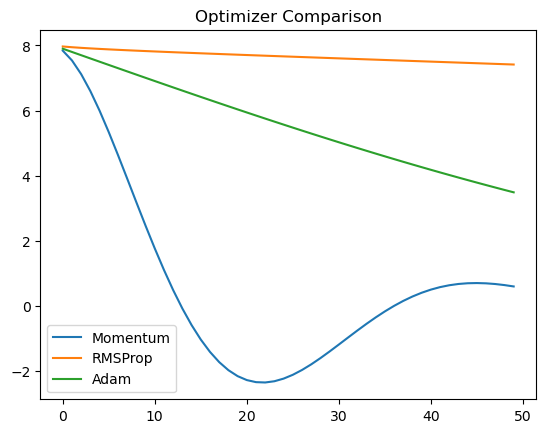

In [7]:
plt.plot(hist_m, label='Momentum')
plt.plot(hist_r, label='RMSProp')
plt.plot(hist_a, label='Adam')
plt.legend()
plt.title("Optimizer Comparison")
plt.show()

## Comparison Summary

| Optimizer | Advantage |
|----------|----------|
| Momentum | Faster convergence |
| RMSProp | Adaptive learning rate |
| Adam | Best overall performance |


## Why This Matters in ML

- Used in deep learning frameworks
- Improves training speed
- Helps models converge better


## Summary

In this notebook we learned:

- Momentum optimization
- RMSProp algorithm
- Adam optimizer
- Practical comparison
